In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Internship\FUTURE_DS_02\WA_Fn-UseC_-Telco-Customer-Churn.csv", encoding='latin1')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges']=df['TotalCharges'].replace(" ",np.nan)

df['TotalCharges']=pd.to_numeric(
    df['TotalCharges']
)

df['TotalCharges']=df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['Churn']=df['Churn'].map({
    'Yes':1,
    'No':0
})

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [10]:
churn_rate = df['Churn'].mean()*100

print("Churn Rate:",round(churn_rate,2),"%")

Churn Rate: 26.54 %


Observation:

Approximately 26.54% customers left the company.

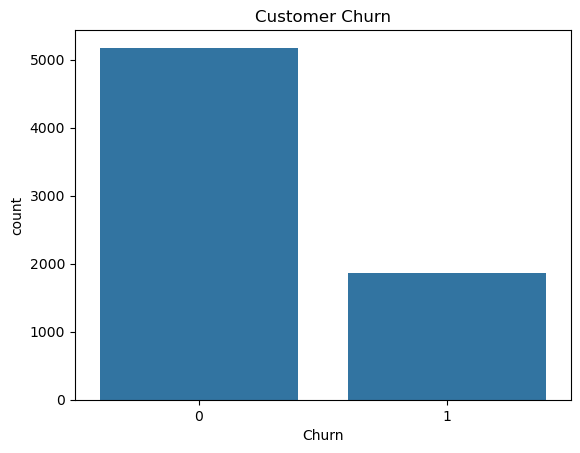

In [11]:
sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn")

plt.show()

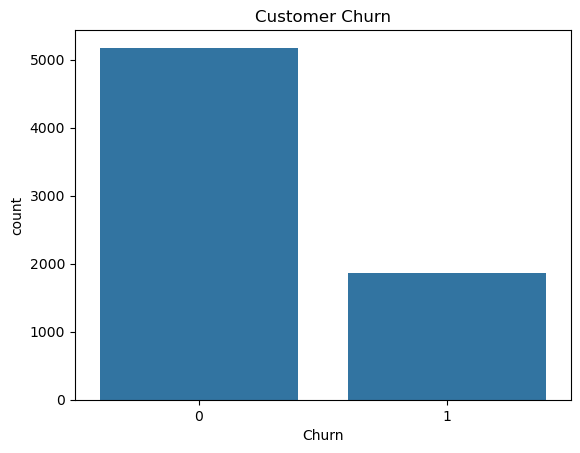

In [12]:
sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn")

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/churn_count.png")

plt.show()

Observation:

The 0 bar is taller than the 1 bar, which means more customers stayed with the company than left.

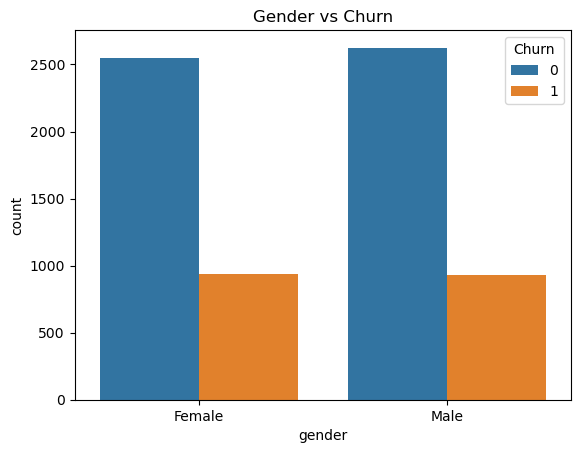

In [14]:
sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title("Gender vs Churn")

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/gender_churn.png")

plt.show()

Observation:

Male customers who stayed (0) are slightly higher than females, while female customers show slightly higher churn (1). The difference is not very large.

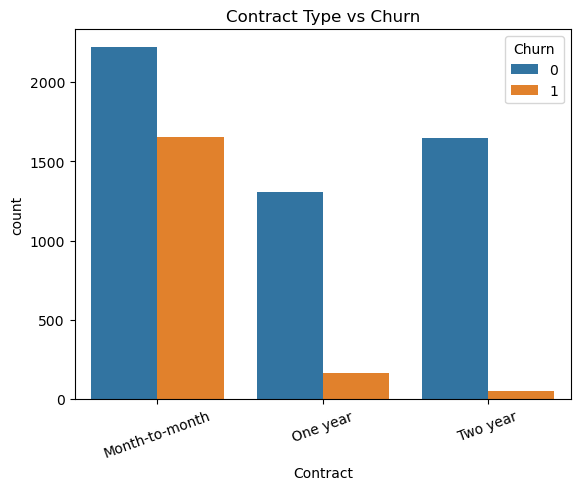

In [15]:
sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=20)

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/contract_churn.png")

plt.show()

Observation:

Month-to-month customers have the highest churn rate. Customers with longer contracts tend to stay longer and churn less.

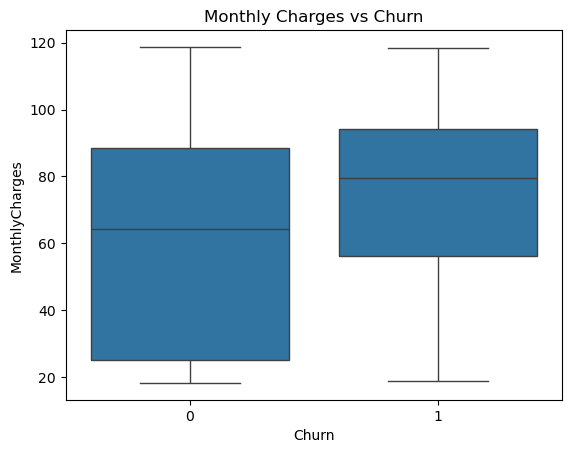

In [16]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/monthlycharges_churn.png")

plt.show()

Observation:

Customers who churned (1) generally have higher monthly charges compared to customers who stayed (0). Higher pricing may contribute to customer churn.

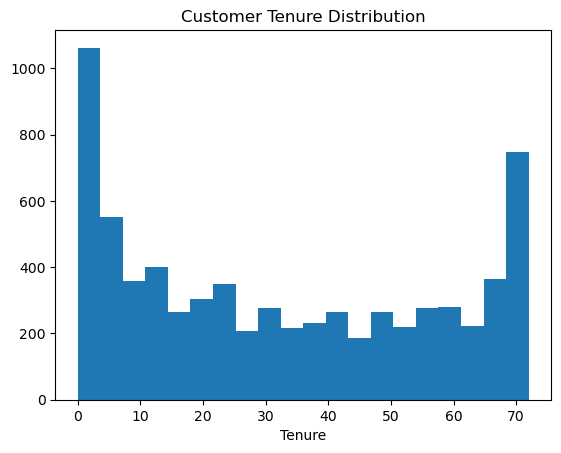

In [17]:
plt.hist(
    df['tenure'],
    bins=20
)

plt.xlabel("Tenure")

plt.title("Customer Tenure Distribution")

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/tenure.png")

plt.show()

Observation:

Customer tenure is higher in the starting months, indicating many customers are relatively new. Early-stage customers may be more likely to churn.

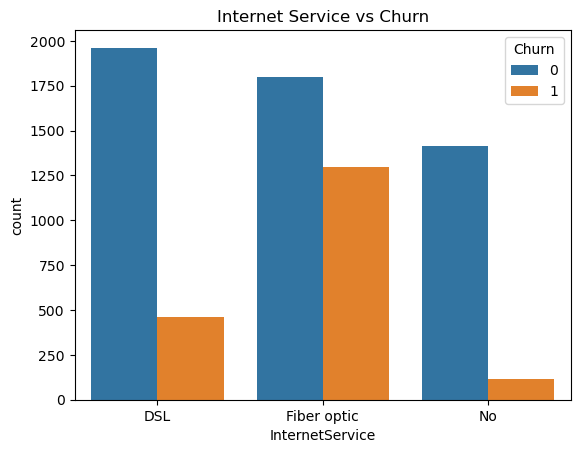

In [18]:
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/internet_churn.png")

plt.show()

Observation:

DSL users show a higher stay rate (0), while Fiber Optic customers have a higher churn rate (1). Fiber users appear more likely to leave the service.

In [19]:
new_df=df.copy()

for i in new_df.columns:

    if new_df[i].dtype=="object":

        new_df[i]=new_df[i].astype(
            'category'
        ).cat.codes

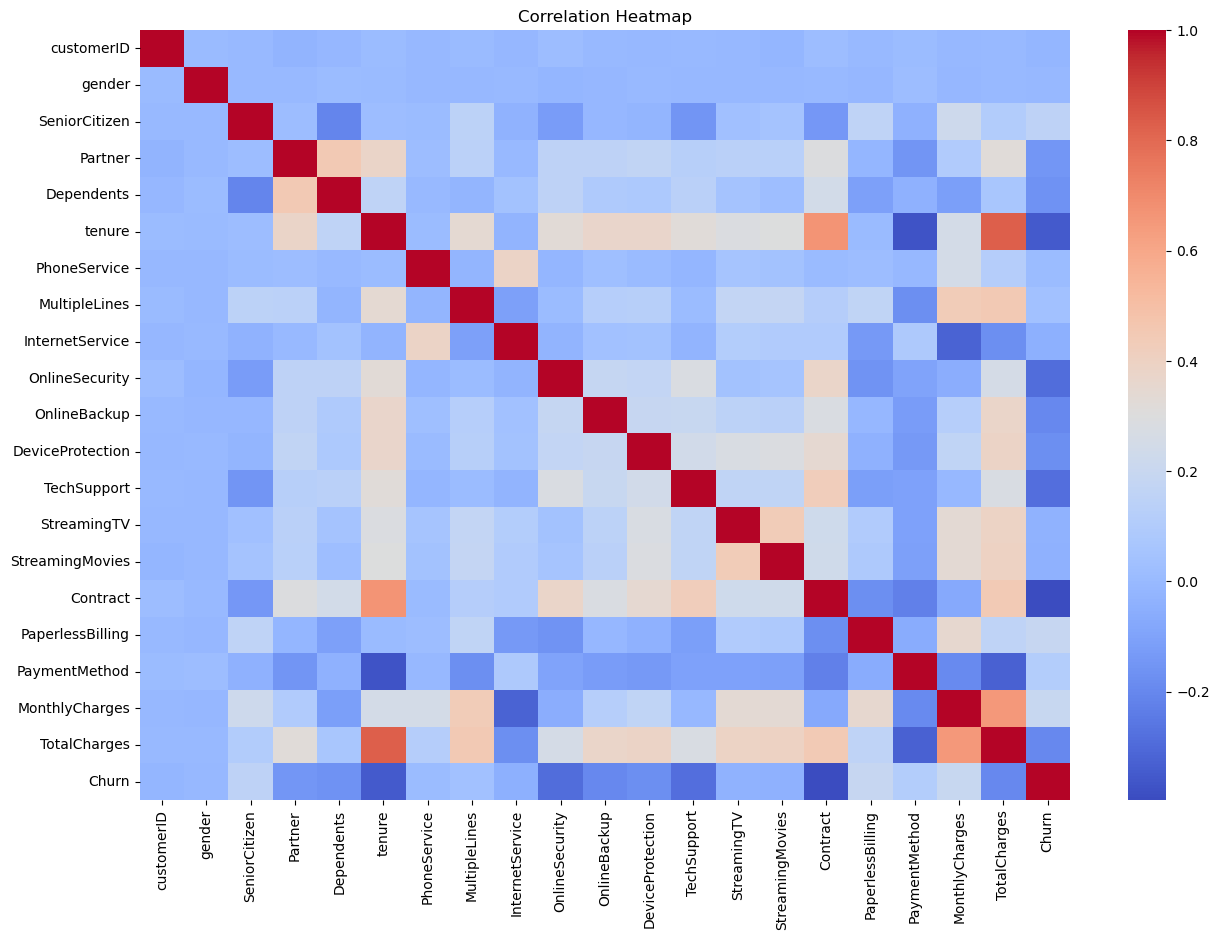

In [20]:
plt.figure(figsize=(15,10))

sns.heatmap(
    new_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("C:/Users/HP/OneDrive/Desktop/Internship/FUTURE_DS_02/images/heatmap.png")

plt.show()

# Key Findings

1. Customer churn rate is approximately 26.54%.

2. More customers stayed with the company than left.

3. Female customers show slightly higher churn than males.

4. Month-to-month customers have the highest churn.

5. Customers with higher monthly charges are more likely to leave.

6. New customers and early-stage users show stronger churn patterns.

7. Fiber optic users have higher churn compared to DSL users.

# Recommendations

- Encourage customers to switch from month-to-month to yearly plans.

- Offer discounts and loyalty rewards.

- Improve onboarding for new users.

- Investigate why Fiber Optic customers leave more frequently.

- Create retention campaigns for customers with high monthly charges.

- Provide personalized offers for at-risk customers.